# Is LD3 a left/right forepaw axis?

`clustering/data_files/mouse_LDA_5_bins_25_18-09-2026` — 269 sessions, 58 mice, LD1…LD25.
The claim under test is that **LD3 separates mice by which forepaw they move more**.

Three views of the same behaviour, at increasing distance from the embedding:

| | what it is | independent of the LDA? |
|---|---|---|
| **syllable use** | occupancy of the 8 HMM paw states — the LDA's own input | no — this is the *mechanism*, what inside the design matrix LD3 reads |
| **paw wavelets** | 0.5–8 Hz velocity band power per paw, per session | different representation, same cameras, no HMM and no trial structure |
| **paw position** | postural spread / excursion of each paw around its own resting point | different representation *and* a different kind of measure (position, not velocity) |

**The confound that governs every number below.** The two forepaws are seen by two
different cameras (left 1280×1024, right 640×512) with different tracking-noise floors
and a multiplicative gain difference. `segmentation/paw_bias` established that the
*population mean* of any laterality index here is instrumental and means nothing, and
that the raw amplitude index correlates r ≈ +0.8 with the 32 Hz tracking-noise index.
Only *individual differences* are interpretable, and only after partialling the noise
index out. Gain-invariant measures (bout rate at matched duty cycle, spectral shape,
lead–lag) are reported alongside because a multiplicative per-camera error cannot touch
them.

In [1]:
"""
CONFIGURATION -- every path and threshold this notebook depends on
==================================================================
Companion module: laterality_features.py (in this folder) does the per-session feature
extraction and caches it to paw_laterality_sessions.csv, so a re-run of this notebook
costs seconds rather than minutes.

RELATED WORK ALREADY IN THE REPO, so this notebook does not re-derive it:
  segmentation/paw_bias/          the paw-bias metrics, their validation and the camera
                                  artefact analysis. README.md there is the reference.
  lab/lda1_vs_raw_paw_laterality.py   the same question asked of LD1 and LD2, against
                                  raw design-matrix positions. This notebook is its LD3
                                  counterpart and reuses its conventions and its
                                  state-LI definition.
"""
LDA_FILE       = 'clustering/data_files/mouse_LDA_5_bins_25_18-09-2026'
SYLLABLE_FILE  = 'data/8_k_10_bin_syllables_19-08-2026'
LD_MAX         = 8        # how many LDs to screen; the embedding has 25
N_PERM         = 10000
ALPHA          = 0.05
EPOCHS         = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']   # pipeline order
N_BINS         = 10       # time bins per epoch in the syllable file
SAVE_FIGS      = False    # True writes to paper-individuality/figures/laterality/

In [2]:
"""IMPORTS AND PATHS"""
import sys
import pathlib
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

HERE = pathlib.Path.cwd()
if HERE.name != 'laterality':          # tolerate being run from the repo root
    HERE = next(p for p in [HERE, *HERE.parents]
                if (p / 'paper-individuality').exists()) / 'paper-individuality/4_mice/laterality'
ROOT = HERE.parent.parent              # .../paper-individuality

# A long-lived kernel caches modules, so edits to laterality_features.py or paper_style.py
# stay invisible until a restart -- reload explicitly, as the other pipeline notebooks do.
for _p in (str(HERE), str(ROOT), str(ROOT / '4_mice'), str(ROOT / 'learning_individuality')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps
import laterality_features as lf
importlib.reload(ps)
importlib.reload(lf)
ps.use('paper')

print('paper-individuality at', ROOT)

paper_style: paper mode, spines=lb, font 7 pt, panels 3.4x2.4 in, save 400 dpi
paper-individuality at /home/ines/repositories/representation_learning_variability/paper-individuality


## 0. The embedding

269 sessions from 58 mice — the `>= 3 sessions` cohort the saved embedding was fit on.
Columns `0..24` become `LD1..LD25`.

**A caveat the pipeline itself raises.** The leading LDA eigenvalues are near-tied, and
near-tied axes are free to rotate among themselves; the notebook that produced this file
says to read them as a subspace rather than as individual axes. So the honest question is
not only "does LD3 track laterality" but "is laterality confined to LD3, or spread over
the leading subspace" — screened in section 5.

In [3]:
lda = pd.read_pickle(ROOT / LDA_FILE)
lda = lda.rename(columns={i: f'LD{i + 1}' for i in range(25)}).set_index('session')
LDS = [f'LD{k}' for k in range(1, LD_MAX + 1)]

print(f'{len(lda)} sessions, {lda.mouse_name.nunique()} mice, {lda.lab.nunique()} labs')
print('sessions per mouse:',
      lda.groupby('mouse_name').size().describe()[['min', '50%', 'max']].to_dict())
lda[LDS].describe().T[['mean', 'std', 'min', 'max']].round(2)

269 sessions, 58 mice, 10 labs
sessions per mouse: {'min': 3.0, '50%': 4.0, 'max': 16.0}


,mean,std,min,max
LD1,0.43,3.37,-10.38,8.83
LD2,0.16,3.03,-9.33,6.80
LD3,0.08,2.55,-10.02,8.27
LD4,0.33,2.68,-7.68,9.24
LD5,0.06,2.37,-5.64,5.47
LD6,-0.04,2.40,-7.12,5.56
LD7,0.02,2.00,-5.91,8.47
LD8,-0.20,2.20,-6.84,4.24


## 1. Which of the 8 HMM paw states are lateralised?

Not assumed — recomputed from `segmentation/paw_bias/state_profiles_19Ago2026.csv`, which
holds each state's mean session-z-scored wavelet power for every (paw, axis, frequency).
`LI` averages the 10 left-paw columns against the 10 right-paw ones.

Two states are clearly left (3, 5) and two clearly right (4, 6); the rest are bilateral —
quiescence (0), low-amplitude (1), slow bilateral (2) and the rare all-out state (7).

,left,right,overall,LI
state,,,,
0,-0.616,-0.600,-0.608,-0.014
1,-0.153,-0.196,-0.174,0.123
2,0.759,0.634,0.697,0.089
3,0.865,0.194,0.530,0.633
4,0.045,0.429,0.237,-0.810
5,2.016,1.059,1.537,0.311
6,0.683,1.634,1.159,-0.410
7,2.939,3.445,3.192,-0.079


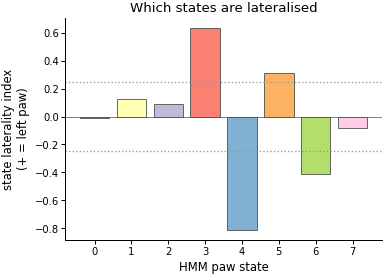

In [4]:
state_li = lf.state_laterality()
display(state_li.round(3))

fig, ax = ps.figure('single')
cols = [ps.SYLLABLE_COLORS[i] for i in state_li.index]
ax.bar(state_li.index, state_li.LI, color=cols, edgecolor='0.3', lw=0.5)
for thr, ls in [(0.25, ':'), (-0.25, ':')]:
    ax.axhline(thr, color='0.6', ls=ls, lw=0.8)
ps.zero_line(ax)
ax.set(xlabel='HMM paw state', ylabel='state laterality index\n(+ = left paw)',
       title='Which states are lateralised')
plt.show()

## 2. Syllable use along LD3

Per-session occupancy of the 8 paw states, from the same file the LDA is built on
(`state = value % 8`, the decomposition the pipeline's own `binarize()` uses). Two
indices:

* `state_LI` — the two left states against the two right ones (the definition
  `lab/lda1_vs_raw_paw_laterality.py` uses, kept identical so the two are comparable).
* `occ_LI` — every state weighted by *its own* profile LI, so the weakly lateralised
  states contribute in proportion rather than being discarded.

The panel that matters is the second one: if LD3 is a laterality axis, a state's
correlation with LD3 should be a straight function of how lateralised that state is.

In [5]:
occ, _sli, left_states, right_states = lf.syllable_features(
    ROOT / SYLLABLE_FILE, sessions=lda.index, state_li=state_li)
print(f'left states {left_states}, right states {right_states}')
print(f'{len(occ)} sessions;  state_LI vs occ_LI  r = '
      f'{occ.state_LI.corr(occ.occ_LI):.3f}')
occ[[f'state{i}' for i in range(8)] + ['whisk', 'lick', 'state_LI', 'occ_LI']].describe().T.round(3)

left states [3, 5], right states [4, 6]
269 sessions;  state_LI vs occ_LI  r = 0.963


,count,mean,std,min,25%,50%,75%,max
state0,269.0,0.116,0.053,0.026,0.077,0.108,0.150,0.395
state1,269.0,0.394,0.056,0.170,0.356,0.389,0.427,0.573
state2,269.0,0.132,0.056,0.027,0.095,0.123,0.163,0.387
state3,269.0,0.093,0.045,0.010,0.060,0.091,0.117,0.297
state4,269.0,0.130,0.056,0.017,0.091,0.128,0.161,0.382
state5,269.0,0.052,0.026,0.005,0.033,0.049,0.069,0.168
state6,269.0,0.075,0.027,0.007,0.059,0.076,0.093,0.195
state7,269.0,0.007,0.005,0.000,0.003,0.006,0.010,0.027
whisk,269.0,0.588,0.122,0.333,0.493,0.574,0.670,0.929
lick,269.0,0.195,0.084,0.023,0.142,0.190,0.248,0.479


,state_LI,occupancy,r_LD3,p_LD3
s,,,,
0,-0.014,0.112,0.204,0.124
1,0.123,0.390,-0.269,0.041
2,0.089,0.135,-0.265,0.045
3,0.633,0.091,-0.445,0.000
4,-0.810,0.135,0.608,0.000
5,0.311,0.052,-0.152,0.256
6,-0.410,0.079,0.165,0.216
7,-0.079,0.007,-0.178,0.181


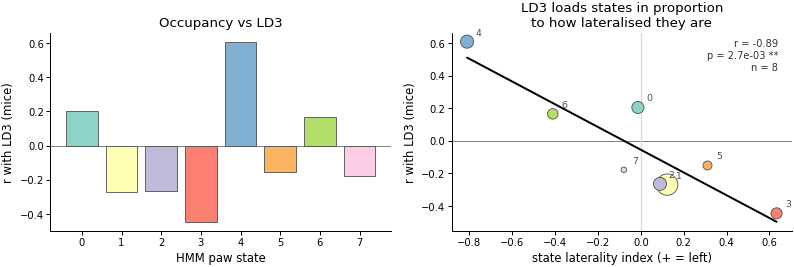

In [6]:
"""
PER-STATE: does a state's relation to LD3 follow how lateralised the state is?
This is the mechanism panel -- it says what inside the design matrix LD3 is reading.
One point per MOUSE, since sessions of one mouse are not independent.
"""
df = lda.join(occ)
mouse_occ = df.groupby('mouse_name').mean(numeric_only=True)

r_state = pd.DataFrame({
    's': range(8),
    'state_LI': state_li.LI.values,
    'occupancy': [mouse_occ[f'state{i}'].mean() for i in range(8)],
    'r_LD3': [stats.pearsonr(mouse_occ.LD3, mouse_occ[f'state{i}'])[0] for i in range(8)],
    'p_LD3': [stats.pearsonr(mouse_occ.LD3, mouse_occ[f'state{i}'])[1] for i in range(8)],
}).set_index('s')
display(r_state.round(3))

fig, axes = plt.subplots(1, 2, figsize=(ps.SIZES[ps.MODE]['single'][0] * 2,
                                        ps.SIZES[ps.MODE]['single'][1]))
ax = axes[0]
ax.bar(r_state.index, r_state.r_LD3, color=[ps.SYLLABLE_COLORS[i] for i in r_state.index],
       edgecolor='0.3', lw=0.5)
ps.zero_line(ax)
ax.set(xlabel='HMM paw state', ylabel='r with LD3 (mice)', title='Occupancy vs LD3')

ax = axes[1]
# marker area ~ occupancy: a state occupied 0.7% of the time cannot move an axis much,
# and without that cue state 7 reads as an equal member of the pattern
ax.scatter(r_state.state_LI, r_state.r_LD3,
           s=400 * r_state.occupancy + 8,
           c=[ps.SYLLABLE_COLORS[i] for i in r_state.index], edgecolors='0.3', lw=0.5,
           zorder=3)
for i, row in r_state.iterrows():
    ax.annotate(str(i), (row.state_LI, row.r_LD3), textcoords='offset points',
                xytext=(5, 4), fontsize=plt.rcParams['font.size'] * 0.8, color='0.3')
_r, _p = stats.pearsonr(r_state.state_LI, r_state.r_LD3)
ps.regline(ax, r_state.state_LI, r_state.r_LD3, _p < ALPHA)
ps.annotate_corr(ax, _r, _p, n=len(r_state), loc='upper right')
ps.zero_line(ax)
ax.axvline(0, color='0.85', lw=0.8, zorder=0)
ax.set(xlabel='state laterality index (+ = left)', ylabel='r with LD3 (mice)',
       title='LD3 loads states in proportion\nto how lateralised they are')
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, 'ld3_state_laterality', subdir='laterality')
plt.show()

## 3. Where in the trial does it live?

The design matrix is 4 epochs × 10 bins × (8 paw states + whisk + lick). Correlating each
cell with LD3 across mice shows whether laterality is a whole-session trait or something
that appears at a particular moment of the trial.

This rebuilds the per-(epoch, bin, channel) occupancy from the raw sequences rather than
re-running the pipeline, so it is a **reconstruction** of the design matrix, not the exact
matrix the LDA saw: the reference-state column is not dropped and no lab correction is
applied. Neither affects a correlation map.

In [7]:
"""Per-session occupancy of every (epoch, time bin, channel), then r with LD3 across mice."""
seq = pd.read_parquet(ROOT / SYLLABLE_FILE,
                      columns=['sample', 'broader_label', 'binned_sequence'])
seq['session'] = seq['sample'].str[:36]
seq = seq[seq.session.isin(lda.index)]

CHANNELS = [f'Paw {i}' for i in range(8)] + ['Whisk', 'Lick']
cells = {}
for (sess, epoch), g in seq.groupby(['session', 'broader_label']):
    if epoch not in EPOCHS:
        continue
    v = np.vstack([np.asarray(s, float) for s in g['binned_sequence'].values])  # trials x bins
    ok = np.isfinite(v)
    iv = np.where(ok, v, 0).astype(int)
    for b in range(v.shape[1]):
        n = ok[:, b].sum()
        if n == 0:
            continue
        col = iv[ok[:, b], b]
        occ_b = np.bincount(col % 8, minlength=8) / n
        cells[(sess, epoch, b)] = np.r_[occ_b, ((col // 8) % 2).mean(), (col // 16).mean()]

M = pd.DataFrame(cells).T
M.index.names = ['session', 'epoch', 'bin']
M.columns = CHANNELS
print(f'reconstructed design matrix: {M.index.get_level_values("session").nunique()} sessions '
      f'x {len(EPOCHS)} epochs x {N_BINS} bins x {len(CHANNELS)} channels')

# one row per mouse per (epoch, bin), so the map is not pseudo-replicated
Mm = (M.join(lda[['mouse_name']], on='session')
        .groupby(['mouse_name', 'epoch', 'bin']).mean())
ld3_mouse = lda.groupby('mouse_name').LD3.mean()

rmap = np.full((len(CHANNELS), len(EPOCHS) * N_BINS), np.nan)
for j, ep in enumerate(EPOCHS):
    for b in range(N_BINS):
        try:
            sub = Mm.xs((ep, b), level=('epoch', 'bin'))
        except KeyError:
            continue
        y = ld3_mouse.reindex(sub.index)
        for i, ch in enumerate(CHANNELS):
            m = np.isfinite(sub[ch]) & np.isfinite(y)
            if m.sum() > 10 and sub[ch][m].std() > 0:
                rmap[i, j * N_BINS + b] = stats.pearsonr(sub[ch][m], y[m])[0]

reconstructed design matrix: 269 sessions x 4 epochs x 10 bins x 10 channels


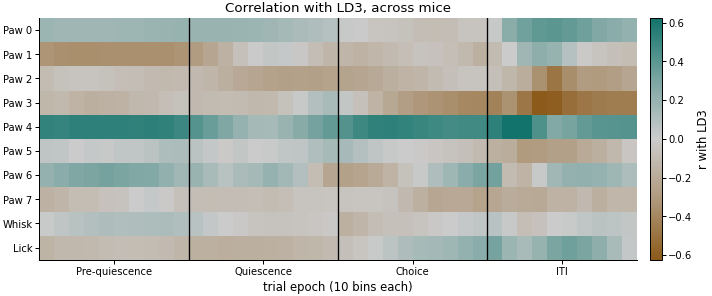

mean r per channel, over the whole trial (SIGNED -- the sign is the whole point):
Paw 0    0.140
Paw 1   -0.130
Paw 2   -0.176
Paw 3   -0.225
Paw 4    0.430
Paw 5   -0.024
Paw 6    0.111
Paw 7   -0.110
Whisk    0.009
Lick     0.011

spread of r across the 40 time bins (SD), per channel -- small = a whole-session trait, large = something that happens at a moment:
Paw 0    0.133
Paw 1    0.160
Paw 2    0.101
Paw 3    0.189
Paw 4    0.125
Paw 5    0.119
Paw 6    0.168
Paw 7    0.068
Whisk    0.071
Lick     0.166


In [8]:
fig, ax = plt.subplots(figsize=(ps.SIZES[ps.MODE]['single'][0] * 1.8,
                                ps.SIZES[ps.MODE]['single'][1] * 1.1))
vmax = np.nanmax(np.abs(rmap))
im = ax.imshow(rmap, aspect='auto', cmap=ps.CORR_CMAP, norm=ps.corr_norm(vmax),
               interpolation='none')
ax.set_yticks(range(len(CHANNELS)), CHANNELS)
ax.set_xticks(np.arange(len(EPOCHS)) * N_BINS + N_BINS / 2 - 0.5, EPOCHS)
for j in range(1, len(EPOCHS)):
    ax.axvline(j * N_BINS - 0.5, color='k', lw=0.8)
ax.set(xlabel='trial epoch (10 bins each)', title='Correlation with LD3, across mice')
fig.colorbar(im, ax=ax, label='r with LD3', fraction=0.03, pad=0.02)
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, 'ld3_design_matrix_map', subdir='laterality')
plt.show()

print('mean r per channel, over the whole trial (SIGNED -- the sign is the whole point):')
print(pd.Series(np.nanmean(rmap, axis=1), index=CHANNELS).round(3).to_string())
print('\nspread of r across the 40 time bins (SD), per channel -- '
      'small = a whole-session trait, large = something that happens at a moment:')
print(pd.Series(np.nanstd(rmap, axis=1), index=CHANNELS).round(3).to_string())

## 4. Raw paw position and wavelets

Straight from `data/paw_wavelets/`, one file per session, carrying both the raw forepaw
coordinates and the velocity wavelets. Computed on the frames where **both** paws are
tracked, so a dropout on one camera cannot shift the index; NaNs are dropped, never
interpolated.

* `li_bandpow` — 0.5–8 Hz velocity power, left against right. The amplitude measure.
* `li_noisepow` — 32 Hz power. A forepaw cannot oscillate at 32 Hz, so this is the
  tracking-noise / camera-gain proxy, and it is the confound.
* `li_exc`, `li_possd`, `li_posiqr` — **position**, not velocity: how far each paw ranges
  around its own resting place, resolution-corrected (left-camera pixels halved).

The first cell checks the extraction against `segmentation/paw_bias/paw_bias_sessions.csv`,
which computed `li_bandpow` and `li_noisepow` independently.

In [9]:
paw = lf.paw_features(sessions=lda.index)
pb = lf.paw_bias_metrics(lda.index)          # validated metrics, '_pb'-suffixed

for a in ('li_bandpow', 'li_noisepow'):
    m = np.isfinite(paw[a]) & np.isfinite(pb[f'{a}_pb'])
    print(f'  {a}: r = {stats.pearsonr(paw[a][m], pb[f"{a}_pb"][m])[0]:.4f} vs paw_bias, '
          f'max |diff| = {np.abs(paw[a][m] - pb[f"{a}_pb"][m]).max():.2e}  (n = {m.sum()})')

print(f'\nsplit-half reliability of li_bandpow within a session: '
      f'r = {stats.pearsonr(paw.li_bandpow_h1, paw.li_bandpow_h2)[0]:.3f}'
      '   <- the measurement ceiling any correlation below is judged against')
print('li_bandpow across sessions: mean %+.3f, sd %.3f   <- the MEAN is instrumental '
      '(camera gain); only the spread is usable'
      % (paw.li_bandpow.mean(), paw.li_bandpow.std()))

data = lda.join(occ).join(paw).join(pb)
print(f'\njoined table: {data.shape[0]} sessions, '
      f'{data.li_bandpow.notna().sum()} with paw features')

cached: paw_laterality_sessions.csv (332 sessions)
  li_bandpow: r = 1.0000 vs paw_bias, max |diff| = 0.00e+00  (n = 269)
  li_noisepow: r = 1.0000 vs paw_bias, max |diff| = 0.00e+00  (n = 269)

split-half reliability of li_bandpow within a session: r = 0.894   <- the measurement ceiling any correlation below is judged against
li_bandpow across sessions: mean -0.066, sd 0.247   <- the MEAN is instrumental (camera gain); only the spread is usable

joined table: 269 sessions, 269 with paw features


## 5. Does LD3 track laterality?

Every measure against LD1…LD8, at the **mouse** level — one point per mouse, the unit that
is not pseudo-replicated (sessions of one mouse are not independent, and section 6 repeats
this at the session level with a mouse-yoked permutation to show it does not depend on the
choice).

`p_perm` shuffles the laterality measure across mice; `p_fdr` is Benjamini–Hochberg across
all measure × LD cells in the table.

In [10]:
MEASURES = {
    'state_LI':        'syllable: left-states − right-states',
    'occ_LI':          'syllable: LI-weighted occupancy',
    'li_bandpow':      'wavelet: 0.5–8 Hz power LI',
    'li_pow_4.0':      'wavelet: 4 Hz power LI',
    'li_exc':          'position: excursion LI',
    'li_possd':        'position: spread LI',
    'li_snr':          'wavelet: SNR LI (gain-invariant, over-corrects)',
    'li_boutrate_pb':  'bouts at matched duty cycle (gain-invariant)',
    'li_shape_4.0_pb': 'spectral shape at 4 Hz (gain-invariant)',
    'lag_s_pb':        'lead–lag, + = left leads (gain-invariant)',
    'xcorr_peak_pb':   'bilateral coupling (not lateralised)',
    'li_noisepow':     '32 Hz tracking noise LI  ⚠ THE CONFOUND',
}

def corr_report(x, y, n_perm=N_PERM, seed=0, groups=None):
    """Pearson r with a permutation p. `groups` (one label per row) shuffles whole
    groups and keeps rows within a group yoked -- the session-level test, where a
    plain shuffle would treat the sessions of one mouse as independent."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    if groups is not None:
        groups = np.asarray(groups)[ok]
    x, y = x[ok], y[ok]
    if len(x) < 5 or x.std() == 0 or y.std() == 0:
        return dict(n=len(x), r=np.nan, p=np.nan, p_perm=np.nan)
    r, p = stats.pearsonr(x, y)
    rng = np.random.default_rng(seed)
    if groups is None:
        null = [abs(np.corrcoef(rng.permutation(x), y)[0, 1]) for _ in range(n_perm)]
    else:
        # one value per group, shuffled across groups, then broadcast back to its rows
        gl, gi = np.unique(groups, return_inverse=True)
        gy = np.array([y[gi == k].mean() for k in range(len(gl))])
        null = []
        for _ in range(n_perm):
            null.append(abs(np.corrcoef(x, rng.permutation(gy)[gi])[0, 1]))
    p_perm = (np.sum(np.asarray(null) >= abs(r)) + 1) / (n_perm + 1)
    return dict(n=len(x), r=r, p=p, p_perm=p_perm)


def fdr(p):
    """Benjamini-Hochberg q-values, NaNs passed through."""
    p = np.asarray(p, float)
    out = np.full(p.shape, np.nan)
    ok = np.isfinite(p)
    o = np.argsort(p[ok])
    q = p[ok][o] * ok.sum() / (np.arange(ok.sum()) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    tmp = np.empty(ok.sum()); tmp[o] = np.minimum(q, 1)
    out[ok] = tmp
    return out

In [11]:
mouse = data.groupby('mouse_name').mean(numeric_only=True)
mouse['lab'] = data.groupby('mouse_name')['lab'].first()
print(f'{len(mouse)} mice')

rows = []
for meas, label in MEASURES.items():
    for ld in LDS:
        rows.append(dict(measure=meas, label=label, LD=ld,
                         **corr_report(mouse[ld], mouse[meas])))
screen = pd.DataFrame(rows)
screen['p_fdr'] = fdr(screen.p_perm)

piv_r = screen.pivot(index='measure', columns='LD', values='r').loc[list(MEASURES)][LDS]
piv_q = screen.pivot(index='measure', columns='LD', values='p_fdr').loc[list(MEASURES)][LDS]
display(piv_r.round(3).style.format('{:+.3f}')
        .background_gradient(cmap=ps.CORR_CMAP, vmin=-0.7, vmax=0.7)
        .set_caption('Pearson r, mouse level (n = %d). Cells below are FDR q.' % len(mouse)))
display(piv_q.round(4))

58 mice


LD,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8
measure,,,,,,,,
state_LI,+0.264,-0.039,-0.606,+0.373,+0.040,+0.121,-0.392,-0.286
occ_LI,+0.327,-0.112,-0.631,+0.346,+0.055,+0.169,-0.307,-0.369
li_bandpow,+0.224,-0.298,-0.615,+0.262,+0.013,+0.188,-0.201,-0.232
li_pow_4.0,+0.201,-0.292,-0.624,+0.296,-0.013,+0.193,-0.182,-0.214
li_exc,+0.101,+0.044,+0.002,-0.000,+0.262,+0.023,-0.064,-0.033
li_possd,+0.053,+0.001,+0.049,-0.107,+0.249,-0.009,-0.037,-0.031
li_snr,+0.245,+0.044,-0.252,+0.135,+0.007,+0.158,+0.119,-0.050
li_boutrate_pb,+0.045,-0.130,+0.240,-0.217,+0.018,-0.005,+0.276,-0.033
li_shape_4.0_pb,-0.050,-0.073,-0.363,+0.412,-0.186,+0.140,+0.032,+0.023


LD,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8
measure,,,,,,,,
state_LI,0.1739,0.9433,0.0024,0.0331,0.9433,0.6047,0.0331,0.1252
occ_LI,0.0751,0.6468,0.0024,0.0487,0.9431,0.4209,0.1029,0.0401
li_bandpow,0.2485,0.1142,0.0024,0.1739,0.9955,0.3570,0.3076,0.2154
li_pow_4.0,0.3076,0.1179,0.0024,0.1142,0.9955,0.3479,0.3621,0.2620
li_exc,0.6747,0.9433,0.9969,0.9969,0.1817,0.9766,0.9176,0.9433
li_possd,0.9431,0.9969,0.9431,0.6617,0.1908,0.9955,0.9433,0.9502
li_snr,0.1908,0.9433,0.1908,0.5313,0.9969,0.4535,0.5948,0.9431
li_boutrate_pb,0.9433,0.5758,0.2025,0.2620,0.9844,0.9969,0.1532,0.9433
li_shape_4.0_pb,0.9431,0.8526,0.0473,0.0219,0.3621,0.5313,0.9433,0.9766


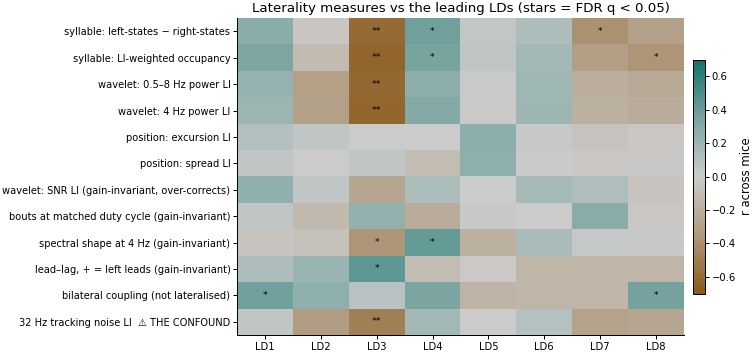

In [12]:
fig, ax = plt.subplots(figsize=(ps.SIZES[ps.MODE]['single'][0] * 1.9,
                                ps.SIZES[ps.MODE]['single'][1] * 1.3))
im = ax.imshow(piv_r.values, cmap=ps.CORR_CMAP, norm=ps.corr_norm(0.7),
               aspect='auto', interpolation='none')
ax.set_xticks(range(len(LDS)), LDS)
ax.set_yticks(range(len(piv_r)), [MEASURES[m] for m in piv_r.index],
              fontsize=plt.rcParams['font.size'] * 0.85)
for i in range(piv_r.shape[0]):
    for j in range(piv_r.shape[1]):
        if np.isfinite(piv_q.values[i, j]) and piv_q.values[i, j] < ALPHA:
            ax.text(j, i, ps.stars(piv_q.values[i, j]), ha='center', va='center',
                    fontsize=plt.rcParams['font.size'] * 0.8, color='k')
fig.colorbar(im, ax=ax, label='r across mice', fraction=0.025, pad=0.02)
ax.set_title('Laterality measures vs the leading LDs (stars = FDR q < %.2f)' % ALPHA)
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, 'ld_screen_laterality', subdir='laterality')
plt.show()

### Is laterality *confined* to LD3?

The pipeline warns that near-tied eigenvalues leave the leading axes free to rotate among
themselves, so a second axis carrying some of the same signal is expected rather than
surprising. Two things to separate:

* how much of a measure LD3 alone explains, against LD1–LD8 jointly (if the two are close,
  LD3 is the axis; if the joint fit is much better, laterality lives in a subspace);
* where the best single direction in that subspace actually points.

In [13]:
"""
HOW MUCH OF EACH MEASURE IS LD3, AND HOW MUCH IS THE REST OF THE SUBSPACE?

R2 from 8 predictors on 58 mice is optimistic, so the in-sample number is reported
next to an adjusted one and a 5-fold cross-validated one. The CV R2 is the one to
read: it can go NEGATIVE, which is what an 8-predictor fit on 58 points looks like
when the extra predictors are noise.
"""
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression


def _cv_r2(X, y, seed=0, n_splits=5):
    X = np.atleast_2d(X.T).T if X.ndim == 1 else X
    pred = np.empty(len(y))
    for tr, te in KFold(n_splits, shuffle=True, random_state=seed).split(X):
        pred[te] = LinearRegression().fit(X[tr], y[tr]).predict(X[te])
    return 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()


def subspace_fit(y_name, lds=LDS):
    y = mouse[y_name].to_numpy(float)
    ok = np.isfinite(y)
    X = mouse.loc[ok, lds].to_numpy(float)
    y = y[ok]
    Xc = (X - X.mean(0)) / X.std(0)
    A = np.c_[np.ones(len(Xc)), Xc]
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    r2_full = 1 - ((y - A @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    n, p = len(y), len(lds)
    r2_adj = 1 - (1 - r2_full) * (n - 1) / (n - p - 1)
    j = lds.index('LD3')
    r2_ld3 = stats.pearsonr(X[:, j], y)[0] ** 2
    w = beta[1:] / np.linalg.norm(beta[1:])
    return dict(measure=y_name, n=n,
                r2_LD3=r2_ld3, cv_r2_LD3=_cv_r2(X[:, [j]], y),
                r2_all=r2_full, r2_all_adj=r2_adj, cv_r2_all=_cv_r2(Xc, y),
                cos_with_LD3=abs(w[j]),
                top=', '.join(f'{lds[i]} {w[i]:+.2f}' for i in np.argsort(-np.abs(w))[:3]))


sub = pd.DataFrame([subspace_fit(m) for m in
                    ['state_LI', 'occ_LI', 'li_bandpow', 'lag_s_pb']]).set_index('measure')
display(sub.round(3))
print('cos_with_LD3 = |component of the best-fitting direction that lies along LD3|.\n'
      'LD3 being the largest single component while LD1-LD8 jointly do better is exactly\n'
      'the picture the pipeline predicts: near-tied eigenvalues leave the leading axes\n'
      'free to rotate, so the laterality direction is CLOSE to LD3 rather than identical\n'
      'to it. Compare cv_r2_LD3 with cv_r2_all to see how much that costs out of sample.')

,n,r2_LD3,cv_r2_LD3,r2_all,r2_all_adj,cv_r2_all,cos_with_LD3,top
measure,,,,,,,,
state_LI,58,0.368,0.290,0.830,0.802,0.727,0.666,"LD3 -0.67, LD7 -0.43, LD4 +0.41"
occ_LI,58,0.398,0.346,0.899,0.882,0.827,0.666,"LD3 -0.67, LD8 -0.39, LD4 +0.36"
li_bandpow,58,0.378,0.302,0.716,0.669,0.482,0.727,"LD3 -0.73, LD2 -0.35, LD4 +0.31"
lag_s_pb,58,0.188,0.110,0.323,0.213,-0.292,0.762,"LD3 +0.76, LD2 +0.36, LD8 -0.28"


cos_with_LD3 = |component of the best-fitting direction that lies along LD3|.
LD3 being the largest single component while LD1-LD8 jointly do better is exactly
the picture the pipeline predicts: near-tied eigenvalues leave the leading axes
free to rotate, so the laterality direction is CLOSE to LD3 rather than identical
to it. Compare cv_r2_LD3 with cv_r2_all to see how much that costs out of sample.


## 6. The controls that decide whether to believe it

1. **The camera confound.** Partial out `li_noisepow` (32 Hz tracking noise). If the
   relation is an artefact of one camera being noisier, it dies here.
2. **Gain-invariant measures.** Bout rate at matched duty cycle, spectral shape and
   lead–lag cannot be moved by a multiplicative per-camera gain at all.
3. **Lab / rig.** Each mouse is normally recorded on one rig, so a rig-geometry effect
   would masquerade as an individual trait. Two tests: how much of each LD a lab label
   explains, and the correlation after centring every variable within its lab.
4. **Session level, mouse-yoked permutation.** Same test without averaging within mouse,
   with a null that shuffles mice rather than sessions.

One reading note for `li_snr`: it is already normalised by each paw's own 32 Hz floor, so partialling `li_noisepow` out of it is not a control but a second, differently-shaped correction of the same quantity. Its *partial* column is therefore not comparable with the others — read its raw row instead.

In [14]:
def partial_corr(x, y, z):
    """r(x, y | z) by residualising both on z (Frisch-Waugh-Lovell), as the neural
    module does. Returns (r, p, n)."""
    x, y, z = (np.asarray(v, float) for v in (x, y, z))
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[m], y[m], z[m]
    if m.sum() < 5:
        return np.nan, np.nan, int(m.sum())
    rx = x - np.polyval(np.polyfit(z, x, 1), z)
    ry = y - np.polyval(np.polyfit(z, y, 1), z)
    r, _ = stats.pearsonr(rx, ry)
    # df drops by one for the covariate, so the p from pearsonr on residuals is optimistic
    n = len(x)
    t = r * np.sqrt((n - 3) / max(1 - r ** 2, 1e-12))
    return r, 2 * stats.t.sf(abs(t), n - 3), n

print('CONTROL 1-2: LD3 vs each measure, raw and partialling out the 32 Hz noise index')
print(f'{"measure":32s}{"raw r":>9s}{"p":>10s}{"partial r":>11s}{"p":>10s}')
ctrl = []
for meas, label in MEASURES.items():
    if meas == 'li_noisepow':
        continue
    raw = corr_report(mouse.LD3, mouse[meas], n_perm=2000)
    pr, pp, n = partial_corr(mouse.LD3, mouse[meas], mouse.li_noisepow)
    ctrl.append(dict(measure=meas, label=label, r=raw['r'], p=raw['p'],
                     p_perm=raw['p_perm'], r_partial=pr, p_partial=pp, n=n))
    print(f'{label[:32]:32s}{raw["r"]:+9.3f}{raw["p"]:10.1e}{pr:+11.3f}{pp:10.1e}')
ctrl = pd.DataFrame(ctrl).set_index('measure')

CONTROL 1-2: LD3 vs each measure, raw and partialling out the 32 Hz noise index
measure                             raw r         p  partial r         p
syllable: left-states − right-st   -0.606   4.5e-07     -0.449   4.6e-04
syllable: LI-weighted occupancy    -0.631   1.1e-07     -0.479   1.6e-04
wavelet: 0.5–8 Hz power LI         -0.615   2.8e-07     -0.426   9.5e-04
wavelet: 4 Hz power LI             -0.624   1.7e-07     -0.442   5.8e-04


position: excursion LI             +0.002   9.9e-01     +0.082   5.4e-01


position: spread LI                +0.049   7.2e-01     +0.124   3.6e-01
wavelet: SNR LI (gain-invariant,   -0.252   5.6e-02     -0.440   6.1e-04
bouts at matched duty cycle (gai   +0.240   7.0e-02     +0.140   3.0e-01
spectral shape at 4 Hz (gain-inv   -0.363   5.1e-03     -0.248   6.3e-02


lead–lag, + = left leads (gain-i   +0.433   6.8e-04     +0.357   6.5e-03


bilateral coupling (not laterali   +0.079   5.6e-01     +0.031   8.2e-01


In [15]:
print('CONTROL 3: lab / rig\n')
print('  how much of each LD does a lab label explain, across mice?')
for ld in LDS[:5]:
    g = [v[ld].values for _, v in mouse.groupby('lab')]
    F, p = stats.f_oneway(*g)
    ss_w = sum(((x - x.mean()) ** 2).sum() for x in g)
    eta2 = 1 - ss_w / ((mouse[ld] - mouse[ld].mean()) ** 2).sum()
    print(f'    {ld}: F = {F:5.2f}  p = {p:.3f}  eta2 = {eta2:.3f}')

print('\n  correlations after centring every variable within its lab:')
cen = mouse.copy()
for col in ['LD3'] + [m for m in MEASURES]:
    if col in cen:
        cen[col] = cen.groupby('lab')[col].transform(lambda s: s - s.mean())
for meas in ['state_LI', 'occ_LI', 'li_bandpow', 'lag_s_pb', 'li_noisepow']:
    r, p = stats.pearsonr(*[v[np.isfinite(cen.LD3) & np.isfinite(cen[meas])]
                            for v in (cen.LD3, cen[meas])])
    print(f'    LD3 vs {MEASURES[meas][:40]:40s} r = {r:+.3f}  p = {p:.1e}')

CONTROL 3: lab / rig

  how much of each LD does a lab label explain, across mice?
    LD1: F =  5.82  p = 0.000  eta2 = 0.522
    LD2: F =  2.84  p = 0.009  eta2 = 0.348
    LD3: F =  0.75  p = 0.665  eta2 = 0.123
    LD4: F =  6.17  p = 0.000  eta2 = 0.536
    LD5: F =  2.09  p = 0.049  eta2 = 0.281

  correlations after centring every variable within its lab:
    LD3 vs syllable: left-states − right-states     r = -0.597  p = 7.5e-07
    LD3 vs syllable: LI-weighted occupancy          r = -0.634  p = 9.0e-08
    LD3 vs wavelet: 0.5–8 Hz power LI               r = -0.635  p = 8.9e-08
    LD3 vs lead–lag, + = left leads (gain-invariant r = +0.402  p = 1.7e-03
    LD3 vs 32 Hz tracking noise LI  ⚠ THE CONFOUND  r = -0.491  p = 9.2e-05


In [16]:
print('CONTROL 4: session level, permutation shuffling MICE (sessions kept yoked)\n')
print(f'{"measure":42s}{"n":>5s}{"r":>9s}{"p":>10s}{"p_perm":>9s}')
sess_rows = []
for meas in ['state_LI', 'occ_LI', 'li_bandpow', 'li_exc', 'lag_s_pb',
             'li_boutrate_pb', 'li_noisepow']:
    res = corr_report(data.LD3, data[meas], groups=data.mouse_name.values)
    sess_rows.append(dict(measure=meas, **res))
    print(f'{MEASURES[meas][:42]:42s}{res["n"]:5d}{res["r"]:+9.3f}'
          f'{res["p"]:10.1e}{res["p_perm"]:9.4f}')
sess = pd.DataFrame(sess_rows).set_index('measure')

CONTROL 4: session level, permutation shuffling MICE (sessions kept yoked)

measure                                       n        r         p   p_perm


syllable: left-states − right-states        269   -0.610   7.6e-29   0.0001


syllable: LI-weighted occupancy             269   -0.644   7.1e-33   0.0001


wavelet: 0.5–8 Hz power LI                  269   -0.585   4.5e-26   0.0001


position: excursion LI                      269   -0.028   6.5e-01   0.8346


lead–lag, + = left leads (gain-invariant)   269   +0.280   3.2e-06   0.0246


bouts at matched duty cycle (gain-invarian  269   +0.224   2.1e-04   0.0778


32 Hz tracking noise LI  ⚠ THE CONFOUND     269   -0.505   8.5e-19   0.0002


## 7. The scatter

LD1 vs LD3 and LD2 vs LD3, one dot per **session**, coloured by the paw laterality index.

The colour scale is centred on the **population median**, not on zero: the zero of any
laterality index here is set by the camera gain, so centring on zero would draw a
left/right split where the instrument happens to sit rather than where the mice do.
Mouse means are overlaid so within- and between-mouse spread can be told apart.

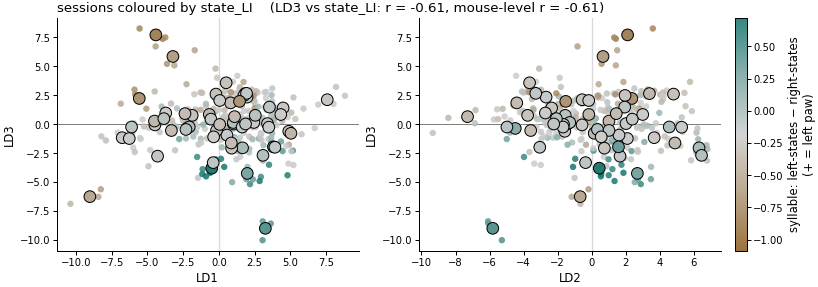

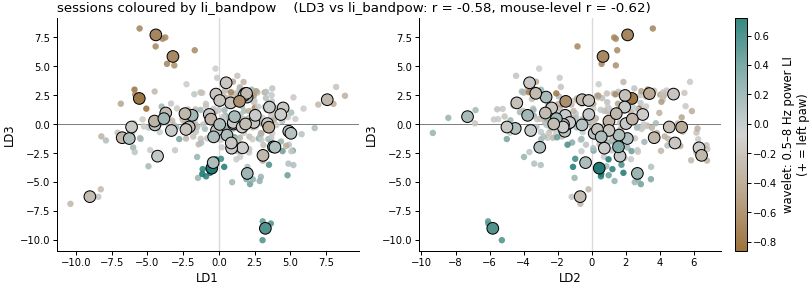

In [17]:
def laterality_scatter(ax, xcol, ycol, cvar, data=data, mouse_means=True,
                       cmap=None, label=None):
    """One dot per session on (xcol, ycol), coloured by cvar, centred on cvar's median."""
    d = data[[xcol, ycol, cvar, 'mouse_name']].dropna()
    import matplotlib.colors as mcolors
    v = d[cvar].to_numpy(float)
    c = float(np.median(v))
    half = max(abs(v - c).max(), 1e-9)
    norm = mcolors.TwoSlopeNorm(vmin=c - half, vcenter=c, vmax=c + half)
    cmap = ps.DIVERGING_CMAP if cmap is None else cmap
    sc = ax.scatter(d[xcol], d[ycol], c=v, cmap=cmap, norm=norm,
                    s=(plt.rcParams['lines.markersize'] * 1.1) ** 2,
                    alpha=0.85, edgecolors='none', zorder=2)
    if mouse_means:
        mm = d.groupby('mouse_name').mean(numeric_only=True)
        ax.scatter(mm[xcol], mm[ycol], c=mm[cvar], cmap=cmap, norm=norm,
                   s=(plt.rcParams['lines.markersize'] * 2.0) ** 2,
                   edgecolors='k', linewidths=0.6, zorder=3)
    ps.zero_line(ax)
    ax.axvline(0, color='0.85', lw=0.8, zorder=0)
    ax.set(xlabel=xcol, ylabel=ycol)
    return sc, norm


for cvar in ['state_LI', 'li_bandpow']:
    fig, axes = plt.subplots(1, 2, figsize=(ps.SIZES[ps.MODE]['single'][0] * 2.2,
                                            ps.SIZES[ps.MODE]['single'][1] * 1.05))
    for ax, x in zip(axes, ['LD1', 'LD2']):
        sc, _ = laterality_scatter(ax, x, 'LD3', cvar)
        r, p = stats.pearsonr(data['LD3'], data[cvar])
    fig.colorbar(sc, ax=axes, label=f'{MEASURES[cvar]}\n(+ = left paw)',
                 fraction=0.025, pad=0.02)
    axes[0].set_title(f'sessions coloured by {cvar}    '
                      f'(LD3 vs {cvar}: r = {r:+.2f}, mouse-level '
                      f'r = {stats.pearsonr(mouse.LD3, mouse[cvar])[0]:+.2f})',
                      loc='left')
    if SAVE_FIGS:
        ps.savefig(fig, f'ld_scatter_{cvar}', subdir='laterality')
    plt.show()

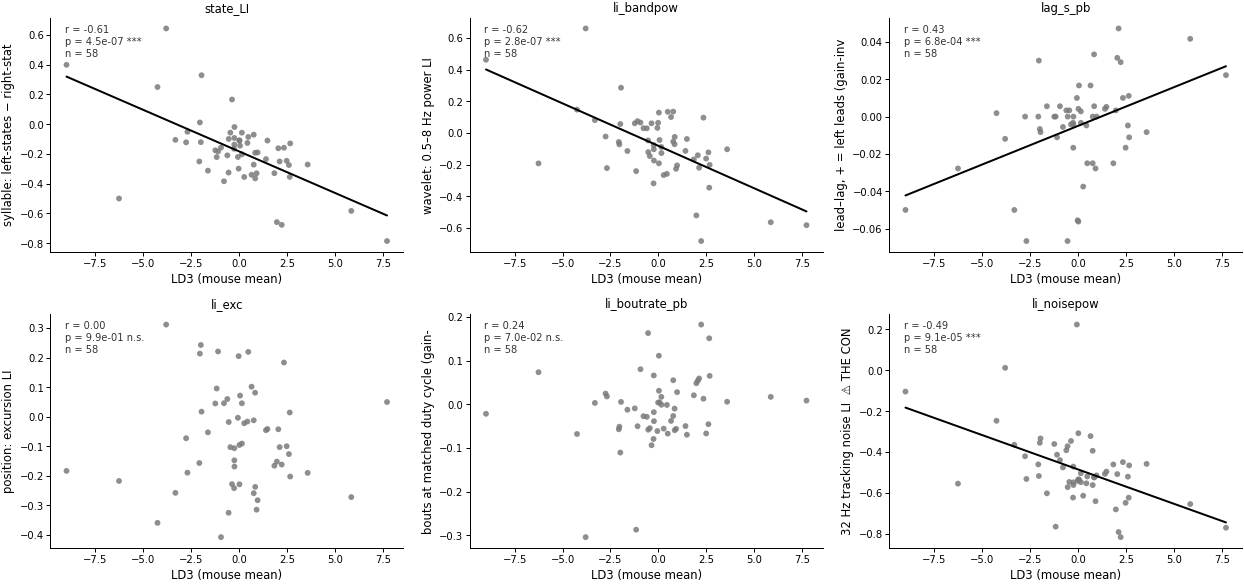

In [18]:
"""The direct panels: LD3 against each laterality measure, one point per mouse."""
show = ['state_LI', 'li_bandpow', 'lag_s_pb', 'li_exc', 'li_boutrate_pb', 'li_noisepow']
fig, axes = plt.subplots(2, 3, figsize=(ps.SIZES[ps.MODE]['single'][0] * 3.1,
                                        ps.SIZES[ps.MODE]['single'][1] * 2.1))
for ax, meas in zip(axes.ravel(), show):
    ps.corr_panel(ax, mouse.LD3, mouse[meas], color=ps.NEUTRAL,
                  xlabel='LD3 (mouse mean)', ylabel=MEASURES[meas][:34])
    ax.set_title(meas, fontsize=plt.rcParams['font.size'])
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, 'ld3_vs_laterality_measures', subdir='laterality')
plt.show()

## 8. Summary

In [19]:
print('=' * 78)
print('IS LD3 A LEFT/RIGHT FOREPAW AXIS?')
print('=' * 78)
print(f'{len(data)} sessions, {len(mouse)} mice, {mouse.lab.nunique()} labs; '
      f'embedding {LDA_FILE.split("/")[-1]}')

best = screen.loc[screen.groupby('measure').r.apply(lambda s: s.abs().idxmax())]
best = best.set_index('measure')
print('\nStrongest LD per measure (mouse level):')
for meas in MEASURES:
    b = best.loc[meas]
    print(f'  {MEASURES[meas][:44]:46s} {b.LD:4s} r = {b.r:+.3f}  q = {b.p_fdr:.4f}')

print('\nLD3 specifically:')
for meas in MEASURES:
    if meas == 'li_noisepow':
        continue
    c = ctrl.loc[meas]
    if not (np.isfinite(c.p_perm) and c.p_perm < ALPHA):
        tag = 'no relation to begin with'          # nothing to survive
    elif np.isfinite(c.p_partial) and c.p_partial < ALPHA:
        tag = 'survives the noise control'
    else:
        tag = 'does NOT survive the noise control'
    print(f'  {MEASURES[meas][:44]:46s} r = {c.r:+.3f} -> partial {c.r_partial:+.3f}  ({tag})')

print('\nSign convention: LI is positive for the LEFT paw, so a NEGATIVE r means '
      'high LD3 = more RIGHT-paw movement.')
print('The MEAN of every index is instrumental (two cameras); only the spread across '
      'mice is interpretable.')

IS LD3 A LEFT/RIGHT FOREPAW AXIS?
269 sessions, 58 mice, 10 labs; embedding mouse_LDA_5_bins_25_18-09-2026

Strongest LD per measure (mouse level):
  syllable: left-states − right-states           LD3  r = -0.606  q = 0.0024
  syllable: LI-weighted occupancy                LD3  r = -0.631  q = 0.0024
  wavelet: 0.5–8 Hz power LI                     LD3  r = -0.615  q = 0.0024
  wavelet: 4 Hz power LI                         LD3  r = -0.624  q = 0.0024
  position: excursion LI                         LD5  r = +0.262  q = 0.1817
  position: spread LI                            LD5  r = +0.249  q = 0.1908
  wavelet: SNR LI (gain-invariant, over-correc   LD3  r = -0.252  q = 0.1908
  bouts at matched duty cycle (gain-invariant)   LD7  r = +0.276  q = 0.1532
  spectral shape at 4 Hz (gain-invariant)        LD4  r = +0.412  q = 0.0219
  lead–lag, + = left leads (gain-invariant)      LD3  r = +0.433  q = 0.0144
  bilateral coupling (not lateralised)           LD1  r = +0.367  q = 0.0401
  32 